# Unsupervised Modeling — Isolation Forest (Layer 2)

## Tại sao cần Layer 2?

### Vấn đề với Layer 1 (Supervised RandomForest)

Model RandomForest đạt Macro F1 = 0.9943 vì **nó học ngược lại chính labeling rules**:

| Feature (importance) | Dùng trong `label_session()` |
|---|---|
| `max_failure_streak` (0.214) | `streak > 5 → class 3` |
| `unique_users_ratio` (0.159) | `ratio > 0.5 → class 2` |
| `failure_ratio` (0.158) | `ratio == 0 → class 0` |
| `has_valid_user_attempt` (0.108) | encodes class 4 |

Đây là **tautology** — model không học patterns mới, chỉ memorize rules.

### Isolation Forest giải quyết gì?

- **Không dùng labels** → không có vấn đề tautology
- Train trên **chỉ Normal sessions** → học distribution thực tế
- Phát hiện **unknown patterns** mà rules chưa cover
- Vai trò: Layer 2 filter — sessions mà Layer 1 classify = Normal nhưng thực ra bất thường

**Nội dung:**
1. Train Isolation Forest trên Normal sessions
2. Tune contamination (false alarm vs detection trade-off)
3. Đánh giá trên toàn dataset + time holdout
4. Score distribution analysis
5. UNKNOWN_PATTERN deep-dive
6. Export model artifacts

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

from feature_engineering import CLASS_NAMES, TRAINING_FEATURES
from anomaly_detector import (
    train_anomaly_detector, score_batch, tune_contamination,
)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

CLASS_LABELS = [CLASS_NAMES[i] for i in range(5)]

---
## 1. Load Data

In [2]:
# Full dataset
X = pd.read_csv(DATA_DIR / 'X_train_ready.csv')
y = pd.read_csv(DATA_DIR / 'y_train_ready.csv').squeeze()

# Time-based splits
X_time_train = pd.read_csv(DATA_DIR / 'X_time_train.csv')
y_time_train = pd.read_csv(DATA_DIR / 'y_time_train.csv').squeeze()
X_time_test  = pd.read_csv(DATA_DIR / 'X_time_test.csv')
y_time_test  = pd.read_csv(DATA_DIR / 'y_time_test.csv').squeeze()

print(f'Full dataset: {X.shape}')
print(f'  Normal sessions (training data for IF): {(y == 0).sum()}')
print(f'  Attack sessions: {(y > 0).sum()}')

print(f'\nTime train: {X_time_train.shape}')
print(f'  Normal: {(y_time_train == 0).sum()}')
print(f'Time test:  {X_time_test.shape}')
print(f'  Normal: {(y_time_test == 0).sum()}, Attack: {(y_time_test > 0).sum()}')

Full dataset: (3916, 11)
  Normal sessions (training data for IF): 123
  Attack sessions: 3793

Time train: (3107, 11)
  Normal: 65
Time test:  (809, 11)
  Normal: 58, Attack: 751


---
## 2. Contamination Tuning

Isolation Forest có 1 hyperparameter quan trọng: `contamination` — tỉ lệ outlier kỳ vọng
trong training data. Tune bằng trade-off:
- **False alarm rate**: % Normal sessions bị flag sai (target < 10%)
- **Detection rate**: % Attack sessions bị bắt đúng (higher = better)

In [3]:
# Train on Normal sessions from time_train, evaluate on time_test
X_train_normal = X_time_train[y_time_train == 0]
print(f'Training IF on {len(X_train_normal)} Normal sessions from time_train\n')

contamination_values = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
tuning_results = tune_contamination(
    X_train_normal, X_time_test, y_time_test,
    contamination_values=contamination_values,
    random_state=RANDOM_STATE,
)

tuning_results

Training IF on 65 Normal sessions from time_train



,contamination,false_alarm_rate,detection_rate,detect_class_0,detect_class_1,detect_class_2,detect_class_3,detect_class_4
0,0.01,0.051724,0.107856,0.051724,0.029070,0.000000,0.201133,0.000000
1,0.02,0.051724,0.143808,0.051724,0.046512,0.021277,0.257790,0.000000
2,0.05,0.155172,0.356858,0.155172,0.206395,0.063830,0.538244,0.571429
3,0.10,0.206897,0.889481,0.206897,0.758721,1.000000,1.000000,1.000000
4,0.15,0.224138,0.890812,0.224138,0.761628,1.000000,1.000000,1.000000
5,0.20,0.224138,0.890812,0.224138,0.761628,1.000000,1.000000,1.000000


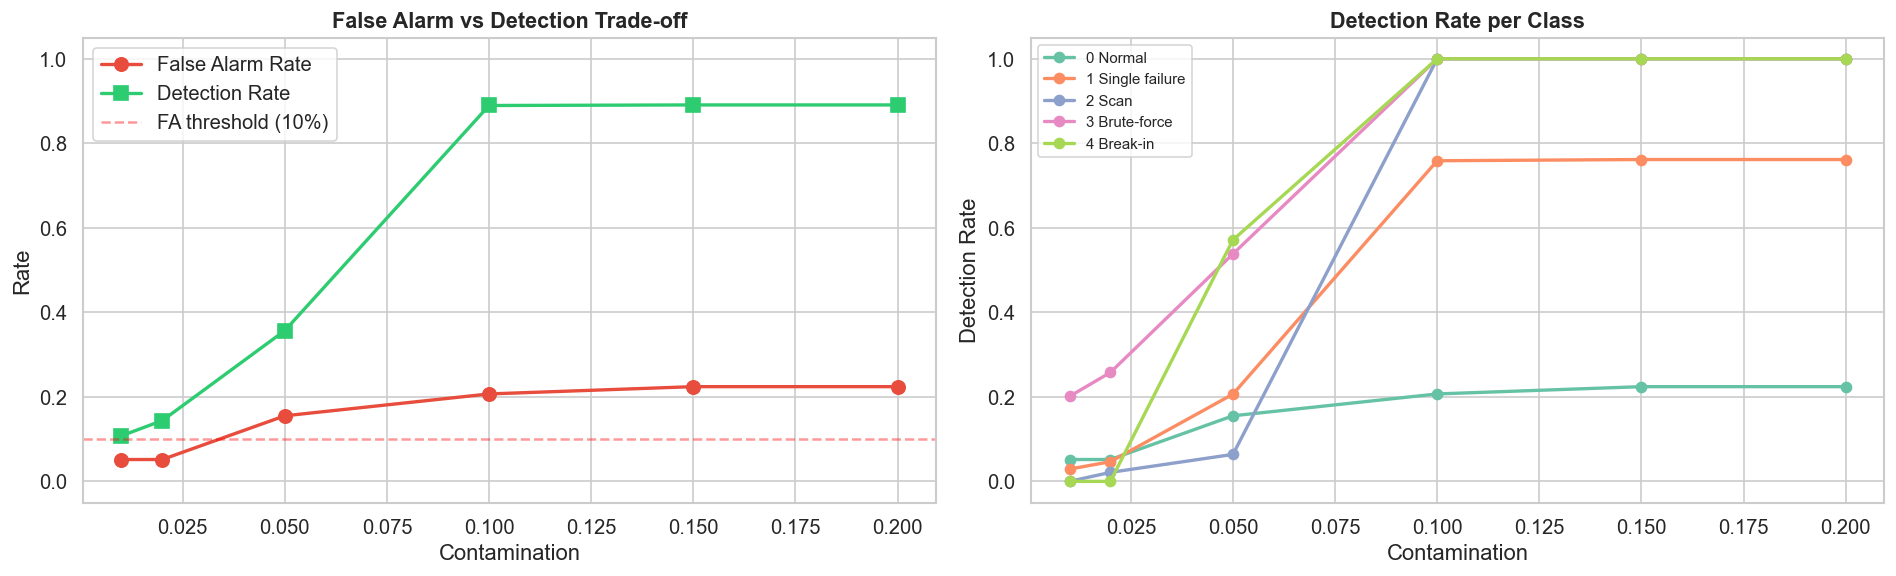

In [4]:
# Visualization: FA vs Detection trade-off
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Trade-off curve
ax = axes[0]
ax.plot(tuning_results['contamination'], tuning_results['false_alarm_rate'],
        'o-', color='#e74c3c', label='False Alarm Rate', linewidth=2, markersize=8)
ax.plot(tuning_results['contamination'], tuning_results['detection_rate'],
        's-', color='#2ecc71', label='Detection Rate', linewidth=2, markersize=8)
ax.axhline(0.10, color='red', linestyle='--', alpha=0.4, label='FA threshold (10%)')
ax.set_xlabel('Contamination')
ax.set_ylabel('Rate')
ax.set_title('False Alarm vs Detection Trade-off', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(-0.05, 1.05)

# Per-class detection rates
ax = axes[1]
detect_cols = [c for c in tuning_results.columns if c.startswith('detect_class_')]
for col in detect_cols:
    cls = int(col.split('_')[-1])
    ax.plot(tuning_results['contamination'], tuning_results[col],
            'o-', label=f'{cls} {CLASS_NAMES[cls]}', linewidth=2, markersize=6)
ax.set_xlabel('Contamination')
ax.set_ylabel('Detection Rate')
ax.set_title('Detection Rate per Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'if_contamination_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Select best contamination: highest detection with FA < 10%
valid = tuning_results[tuning_results['false_alarm_rate'] <= 0.10]
if len(valid) > 0:
    best_row = valid.loc[valid['detection_rate'].idxmax()]
    best_contamination = best_row['contamination']
else:
    # Fallback: lowest FA
    best_row = tuning_results.loc[tuning_results['false_alarm_rate'].idxmin()]
    best_contamination = best_row['contamination']
    print('Warning: no contamination achieved FA < 10%, using lowest FA')

print(f'Selected contamination: {best_contamination}')
print(f'  False alarm rate: {best_row["false_alarm_rate"]:.1%}')
print(f'  Detection rate:   {best_row["detection_rate"]:.1%}')

Selected contamination: 0.02
  False alarm rate: 5.2%
  Detection rate:   14.4%


---
## 3. Train Final Isolation Forest

Train trên **tất cả Normal sessions** (full dataset, class=0) với contamination đã chọn.

In [6]:
# Train on ALL normal sessions from full dataset
iso_model = train_anomaly_detector(
    X, y,
    contamination=best_contamination,
    random_state=RANDOM_STATE,
)

n_normal = (y == 0).sum()
print(f'Isolation Forest trained on {n_normal} Normal sessions')
print(f'  contamination = {best_contamination}')
print(f'  n_estimators  = {iso_model.n_estimators}')
print(f'  max_samples   = {iso_model.max_samples}')

Isolation Forest trained on 123 Normal sessions
  contamination = 0.02
  n_estimators  = 200
  max_samples   = auto


---
## 4. Evaluation — Full Dataset

Score toàn bộ 3,916 sessions và phân tích:
- Isolation Forest coi sessions nào là "anomalous"?
- Có trùng với labeling rules không? (Nếu trùng 100% thì IF cũng tautological)

In [7]:
# Score all sessions
scores_all, preds_all = score_batch(iso_model, X)

# Add to dataframe for analysis
analysis_df = X.copy()
analysis_df['class'] = y
analysis_df['class_label'] = y.map(CLASS_NAMES)
analysis_df['anomaly_score'] = scores_all
analysis_df['is_anomaly'] = preds_all

print('=== Isolation Forest on Full Dataset ===\n')
print(f'Total sessions:  {len(analysis_df)}')
print(f'Flagged anomaly: {preds_all.sum()} ({preds_all.mean():.1%})\n')

# Per-class results
print(f'{"Class":<20} {"Count":>7} {"Flagged":>8} {"Rate":>8} {"Avg Score":>10}')
print('-' * 58)
for cls in range(5):
    mask = y == cls
    n = mask.sum()
    flagged = preds_all[mask].sum()
    rate = flagged / n if n > 0 else 0
    avg_score = scores_all[mask].mean()
    print(f'{cls} {CLASS_NAMES[cls]:17s} {n:>7} {flagged:>8} {rate:>7.1%} {avg_score:>10.4f}')

=== Isolation Forest on Full Dataset ===

Total sessions:  3916
Flagged anomaly: 249 (6.4%)

Class                  Count  Flagged     Rate  Avg Score
----------------------------------------------------------
0 Normal                123        2    1.6%     0.2906
1 Single failure       2542        9    0.4%     0.1205
2 Scan                  192        1    0.5%     0.0991
3 Brute-force          1040      237   22.8%     0.0528
4 Break-in               19        0    0.0%     0.1165


In [8]:
# Binary evaluation: Normal (0) vs Attack (1-4)
y_binary = (y > 0).astype(int)
preds_binary = preds_all  # IF: 1=anomaly, 0=normal

print('=== Binary Evaluation (Normal vs Attack) ===\n')
print(classification_report(
    y_binary, preds_binary,
    target_names=['Normal', 'Attack'],
    digits=4,
))

# Confusion matrix
cm = confusion_matrix(y_binary, preds_binary)
print(f'Confusion matrix (raw):')
print(f'  True Normal  → Pred Normal: {cm[0,0]:>5}, Pred Anomaly: {cm[0,1]:>5}')
print(f'  True Attack  → Pred Normal: {cm[1,0]:>5}, Pred Anomaly: {cm[1,1]:>5}')

=== Binary Evaluation (Normal vs Attack) ===

              precision    recall  f1-score   support

      Normal     0.0330    0.9837    0.0639       123
      Attack     0.9920    0.0651    0.1222      3793

    accuracy                         0.0940      3916
   macro avg     0.5125    0.5244    0.0930      3916
weighted avg     0.9618    0.0940    0.1204      3916

Confusion matrix (raw):
  True Normal  → Pred Normal:   121, Pred Anomaly:     2
  True Attack  → Pred Normal:  3546, Pred Anomaly:   247


---
## 5. Score Distribution Analysis

Anomaly score thấp hơn = bất thường hơn. Phân tích score distribution
cho thấy IF "nhìn" data khác rules hay không.

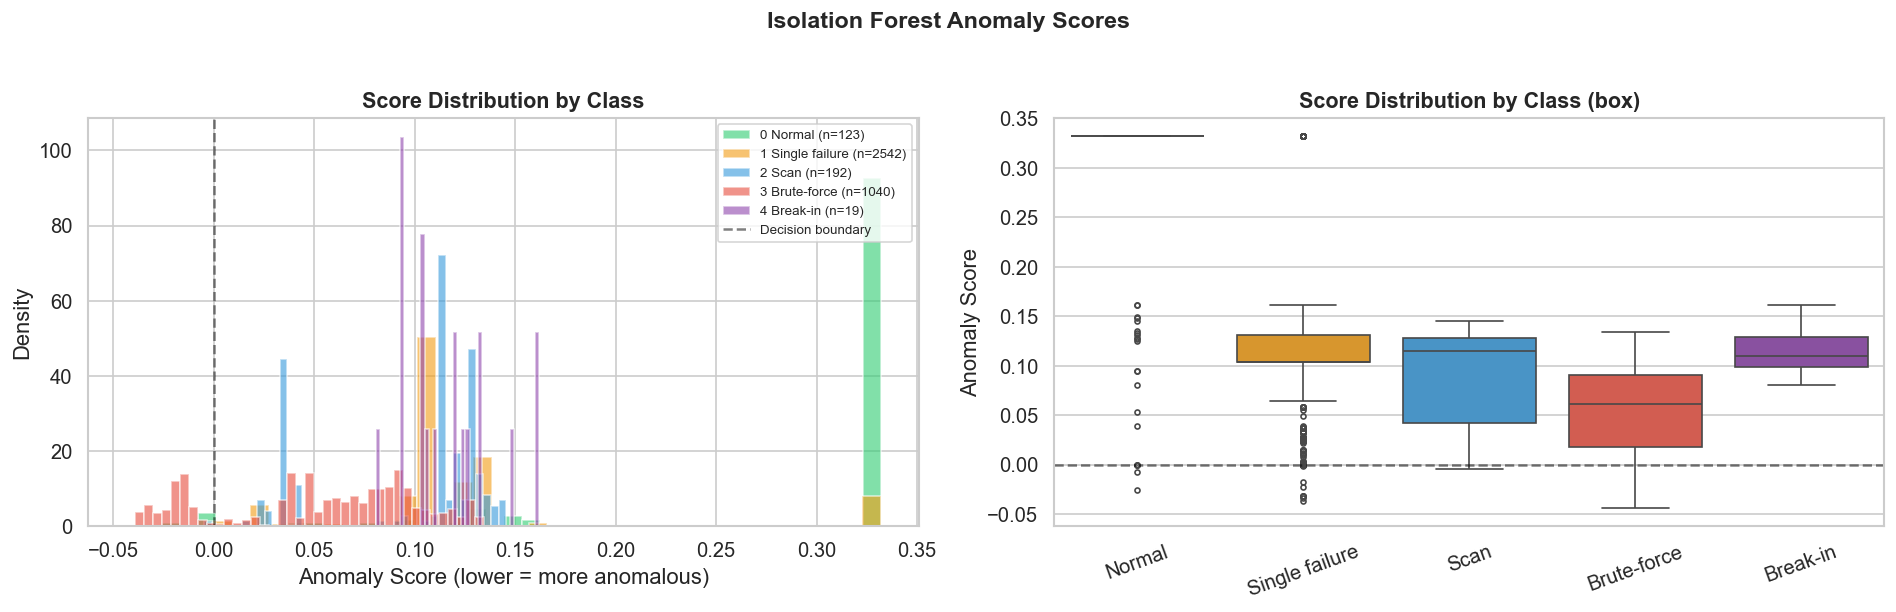

In [9]:
# Score distribution by class
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram by class
ax = axes[0]
class_colors = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c', '#8e44ad']
for cls in range(5):
    mask = y == cls
    ax.hist(scores_all[mask], bins=40, alpha=0.6,
            label=f'{cls} {CLASS_NAMES[cls]} (n={mask.sum()})',
            color=class_colors[cls], density=True)
ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Decision boundary')
ax.set_xlabel('Anomaly Score (lower = more anomalous)')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by Class', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)

# Box plot
ax = axes[1]
order = [CLASS_NAMES[i] for i in range(5)]
palette = {CLASS_NAMES[i]: c for i, c in enumerate(class_colors)}
sns.boxplot(data=analysis_df, x='class_label', y='anomaly_score',
            order=order, palette=palette, ax=ax, fliersize=3)
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('')
ax.set_ylabel('Anomaly Score')
ax.set_title('Score Distribution by Class (box)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=20)

plt.suptitle('Isolation Forest Anomaly Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'if_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Score statistics by class
print(f'{"Class":<20} {"Min":>8} {"Q1":>8} {"Median":>8} {"Q3":>8} {"Max":>8}')
print('-' * 60)
for cls in range(5):
    s = scores_all[y == cls]
    q1, med, q3 = np.percentile(s, [25, 50, 75])
    print(f'{cls} {CLASS_NAMES[cls]:17s} {s.min():>8.4f} {q1:>8.4f} {med:>8.4f} {q3:>8.4f} {s.max():>8.4f}')

Class                     Min       Q1   Median       Q3      Max
------------------------------------------------------------
0 Normal             -0.0256   0.3320   0.3320   0.3320   0.3320
1 Single failure     -0.0370   0.1042   0.1042   0.1315   0.3320
2 Scan               -0.0046   0.0426   0.1150   0.1284   0.1455
3 Brute-force        -0.0435   0.0176   0.0614   0.0902   0.1344
4 Break-in            0.0806   0.0992   0.1100   0.1292   0.1619


---
## 6. Time-based Holdout Evaluation

In [11]:
# Score holdout test set
scores_test, preds_test = score_batch(iso_model, X_time_test)

print('=== Time Holdout Evaluation ===\n')
print(f'{"Class":<20} {"Count":>7} {"Flagged":>8} {"Rate":>8}')
print('-' * 48)
for cls in range(5):
    mask = y_time_test == cls
    n = mask.sum()
    flagged = preds_test[mask.values].sum()
    rate = flagged / n if n > 0 else 0
    print(f'{cls} {CLASS_NAMES[cls]:17s} {n:>7} {flagged:>8} {rate:>7.1%}')

# Small class warning
print()
for cls in range(5):
    n = (y_time_test == cls).sum()
    if n < 10:
        print(f'  Warning: class {cls} ({CLASS_NAMES[cls]}) has only {n} samples in holdout')

=== Time Holdout Evaluation ===

Class                  Count  Flagged     Rate
------------------------------------------------
0 Normal                 58        1    1.7%
1 Single failure        344        2    0.6%
2 Scan                   47        1    2.1%
3 Brute-force           353       71   20.1%
4 Break-in                7        0    0.0%



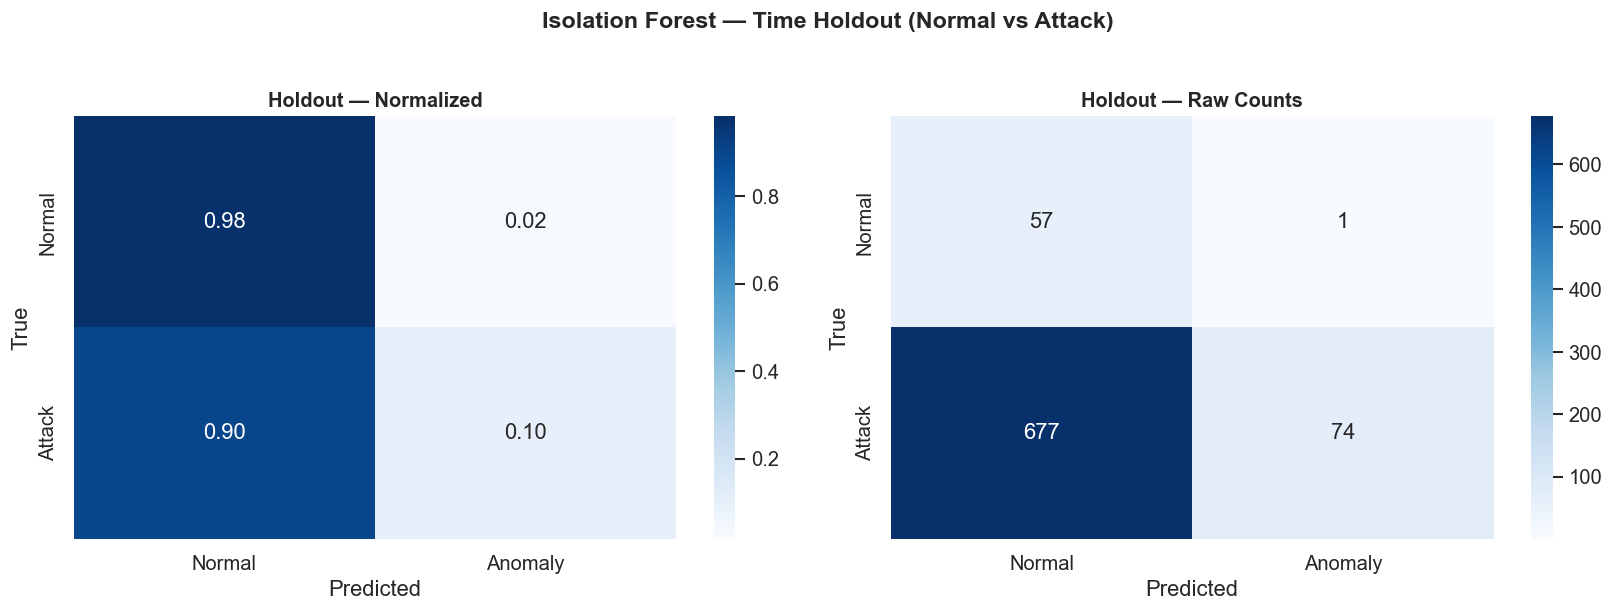

In [12]:
# Holdout confusion matrix (binary: Normal vs Attack)
y_test_binary = (y_time_test > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_norm = confusion_matrix(y_test_binary, preds_test, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Attack'], ax=axes[0])
axes[0].set_title('Holdout — Normalized', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_raw = confusion_matrix(y_test_binary, preds_test)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Attack'], ax=axes[1])
axes[1].set_title('Holdout — Raw Counts', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Isolation Forest — Time Holdout (Normal vs Attack)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'if_holdout_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. UNKNOWN_PATTERN Deep-dive

Hybrid logic: `Layer1 = Normal (class 0)` + `Layer2 = anomaly` → **UNKNOWN_PATTERN**.

Simulate: trong Layer 1 supervised labels, sessions class=0 (Normal) nào bị IF flag?

In [13]:
# Normal sessions flagged as anomalous by IF
normal_mask = y == 0
normal_flagged = analysis_df[normal_mask & (analysis_df['is_anomaly'] == 1)]

print(f'Normal sessions total: {normal_mask.sum()}')
print(f'Normal sessions flagged by IF: {len(normal_flagged)} ({len(normal_flagged)/normal_mask.sum():.1%})')
print(f'\nThese would be UNKNOWN_PATTERN alerts in the hybrid system.\n')

if len(normal_flagged) > 0:
    print('Feature profile of UNKNOWN_PATTERN sessions:')
    feature_cols = [c for c in X.columns if c != 'is_private']
    normal_not_flagged = analysis_df[normal_mask & (analysis_df['is_anomaly'] == 0)]

    print(f'\n{"Feature":<28} {"Normal (OK)":>14} {"Normal (flagged)":>18} {"Diff":>10}')
    print('-' * 74)
    for feat in feature_cols:
        ok_mean = normal_not_flagged[feat].mean()
        fl_mean = normal_flagged[feat].mean()
        diff = fl_mean - ok_mean
        marker = ' ***' if abs(diff) > 0.5 else ''
        print(f'{feat:<28} {ok_mean:>14.4f} {fl_mean:>18.4f} {diff:>+10.4f}{marker}')

    print('\n*** = large deviation from normal Normal sessions')
else:
    print('No Normal sessions flagged — IF agrees with rules completely for class 0.')

Normal sessions total: 123
Normal sessions flagged by IF: 2 (1.6%)

These would be UNKNOWN_PATTERN alerts in the hybrid system.

Feature profile of UNKNOWN_PATTERN sessions:

Feature                         Normal (OK)   Normal (flagged)       Diff
--------------------------------------------------------------------------
session_duration                     0.4459             3.2416    +2.7956 ***
attempts_per_second                  0.0252             0.5516    +0.5263 ***
is_single_event                      0.8678             0.0000    -0.8678 ***
failure_ratio                        0.0000             0.0000    +0.0000
unique_users_ratio                   0.0526             0.4167    +0.3640
has_root_attempt                     0.0000             0.0000    +0.0000
has_valid_user_attempt               1.0000             1.0000    +0.0000
max_failure_streak                   0.0000             0.0000    +0.0000
invalid_user_attempts                0.0000             0.0000    +0.000

In [14]:
# Attack sessions NOT flagged by IF (missed attacks)
attack_mask = y > 0
attack_missed = analysis_df[attack_mask & (analysis_df['is_anomaly'] == 0)]

print(f'Attack sessions total: {attack_mask.sum()}')
print(f'Attack sessions NOT flagged by IF: {len(attack_missed)} ({len(attack_missed)/attack_mask.sum():.1%})')
print(f'\nThese attacks would be classified as NORMAL by IF alone.\n')

if len(attack_missed) > 0:
    # Show class distribution of missed attacks
    print('Missed attacks by class:')
    for cls in range(1, 5):
        cls_mask = attack_missed['class'] == cls
        total_cls = (y == cls).sum()
        missed = cls_mask.sum()
        print(f'  {cls} {CLASS_NAMES[cls]:17s}: {missed:>5} / {total_cls:>5} missed ({missed/total_cls:.1%})')

    print(f'\n-> This is why Layer 1 (supervised) is still needed for known patterns.')
    print(f'-> IF complements Layer 1 by catching unknown patterns, not replacing it.')

Attack sessions total: 3793
Attack sessions NOT flagged by IF: 3546 (93.5%)

These attacks would be classified as NORMAL by IF alone.

Missed attacks by class:
  1 Single failure   :  2533 /  2542 missed (99.6%)
  2 Scan             :   191 /   192 missed (99.5%)
  3 Brute-force      :   803 /  1040 missed (77.2%)
  4 Break-in         :    19 /    19 missed (100.0%)

-> This is why Layer 1 (supervised) is still needed for known patterns.
-> IF complements Layer 1 by catching unknown patterns, not replacing it.


---
## 8. Layer 1 vs Layer 2 Comparison

So sánh trực tiếp: supervised model (tautological) vs unsupervised model (data-driven).

In [15]:
# Load Layer 1 model for comparison
rf_model = joblib.load(MODEL_DIR / 'best_model.pkl')
rf_preds = rf_model.predict(X)

# Hybrid logic
hybrid_alerts = []
for i in range(len(X)):
    l1_class = rf_preds[i]
    l2_anomaly = preds_all[i]
    if l1_class > 0:
        alert_type = 'KNOWN_ATTACK'
    elif l2_anomaly:
        alert_type = 'UNKNOWN_PATTERN'
    else:
        alert_type = 'NORMAL'
    hybrid_alerts.append(alert_type)

analysis_df['hybrid_alert'] = hybrid_alerts

print('=== Hybrid Detection Results ===\n')
alert_dist = pd.Series(hybrid_alerts).value_counts()
for alert_type in ['NORMAL', 'KNOWN_ATTACK', 'UNKNOWN_PATTERN']:
    count = alert_dist.get(alert_type, 0)
    print(f'  {alert_type:20s}: {count:>5} ({count/len(X):.1%})')

# What classes do UNKNOWN_PATTERN cover?
unknown = analysis_df[analysis_df['hybrid_alert'] == 'UNKNOWN_PATTERN']
if len(unknown) > 0:
    print(f'\nUNKNOWN_PATTERN sessions by true class:')
    for cls in range(5):
        n = (unknown['class'] == cls).sum()
        if n > 0:
            print(f'  {cls} {CLASS_NAMES[cls]:17s}: {n}')

=== Hybrid Detection Results ===

  NORMAL              :   121 (3.1%)
  KNOWN_ATTACK        :  3793 (96.9%)
  UNKNOWN_PATTERN     :     2 (0.1%)

UNKNOWN_PATTERN sessions by true class:
  0 Normal           : 2


In [16]:
# Feature importance proxy: which features contribute most to anomaly detection?
# Use score correlation with individual features
print('=== Feature Contribution to Anomaly Scores ===\n')
print('Correlation between anomaly_score and features')
print('(negative = feature increases anomaly probability)\n')

correlations = []
for col in X.columns:
    corr = np.corrcoef(X[col].values, scores_all)[0, 1]
    correlations.append((col, corr))

correlations.sort(key=lambda x: x[1])
for feat, corr in correlations:
    direction = 'anomalous' if corr < 0 else 'normal'
    bar = '#' * int(abs(corr) * 30)
    print(f'  {feat:30s}: {corr:+.4f} [{direction:>9s}] {bar}')

=== Feature Contribution to Anomaly Scores ===

Correlation between anomaly_score and features
(negative = feature increases anomaly probability)

  has_reverse_mapping_failed    : -0.5365 [anomalous] ################
  session_duration              : -0.4656 [anomalous] #############
  max_failure_streak            : -0.4516 [anomalous] #############
  invalid_user_attempts         : -0.4505 [anomalous] #############
  failure_ratio                 : -0.4286 [anomalous] ############
  attempts_per_second           : -0.4221 [anomalous] ############
  unique_users_ratio            : -0.2254 [anomalous] ######
  has_root_attempt              : -0.0603 [anomalous] #
  is_private                    : +0.0473 [   normal] #
  has_valid_user_attempt        : +0.4081 [   normal] ############
  is_single_event               : +0.7697 [   normal] #######################


---
## 9. Export Artifacts

In [17]:
# 1. Save Isolation Forest model
iso_path = MODEL_DIR / 'anomaly_detector.pkl'
joblib.dump(iso_model, iso_path)
print(f'[1] Anomaly detector:     {iso_path}')

# 2. Save tuning results
tuning_path = MODEL_DIR / 'if_contamination_tuning.csv'
tuning_results.to_csv(tuning_path, index=False)
print(f'[2] Tuning results:       {tuning_path}')

# 3. Save full analysis with scores
scores_path = MODEL_DIR / 'if_session_scores.csv'
score_export = pd.DataFrame({
    'class': y,
    'class_label': y.map(CLASS_NAMES),
    'anomaly_score': scores_all,
    'is_anomaly': preds_all,
    'hybrid_alert': hybrid_alerts,
})
score_export.to_csv(scores_path, index=False)
print(f'[3] Session scores:       {scores_path}')

print(f'\nAll artifacts saved to: {MODEL_DIR.resolve()}')
for f in sorted(MODEL_DIR.iterdir()):
    if f.is_file() and f.name != '.gitkeep':
        size_kb = f.stat().st_size / 1024
        print(f'  {f.name:40s} {size_kb:>8.1f} KB')

[1] Anomaly detector:     ..\models\anomaly_detector.pkl
[2] Tuning results:       ..\models\if_contamination_tuning.csv
[3] Session scores:       ..\models\if_session_scores.csv

All artifacts saved to: D:\SSH-anomaly-detection-using-ML\models
  anomaly_detector.pkl                        659.9 KB
  best_model.pkl                             1127.5 KB
  confusion_matrix.png                        103.4 KB
  cv_classification_report.txt                  0.6 KB
  cv_confusion_matrices.png                   105.6 KB
  feature_importance.csv                        0.4 KB
  feature_importance.png                       71.9 KB
  holdout_classification_report.txt             0.6 KB
  if_contamination_tuning.csv                   0.8 KB
  if_contamination_tuning.png                 124.2 KB
  if_holdout_confusion.png                     57.9 KB
  if_score_distribution.png                   111.0 KB
  if_session_scores.csv                       195.6 KB
  model_comparison.csv                  

In [18]:
# Final summary
print('=' * 60)
print('UNSUPERVISED MODELING COMPLETE')
print('=' * 60)

print(f'\nIsolation Forest:')
print(f'  Training data:    {n_normal} Normal sessions')
print(f'  contamination:    {best_contamination}')
print(f'  n_estimators:     200')

# Key insight
fa_rate = preds_all[y == 0].mean()
det_rate = preds_all[y > 0].mean()
print(f'\nPerformance (full dataset):')
print(f'  False alarm (Normal flagged): {fa_rate:.1%}')
print(f'  Detection (Attack flagged):   {det_rate:.1%}')

print(f'\nHybrid detection summary:')
for alert_type in ['NORMAL', 'KNOWN_ATTACK', 'UNKNOWN_PATTERN']:
    count = alert_dist.get(alert_type, 0)
    print(f'  {alert_type:20s}: {count:>5}')

print(f'\nConceptual difference from Layer 1:')
print(f'  Layer 1 (RF):  learns labeling rules back (tautological)')
print(f'  Layer 2 (IF):  learns Normal data distribution (data-driven)')
print(f'  Hybrid:        Layer 1 catches known attacks, Layer 2 catches unknown')

UNSUPERVISED MODELING COMPLETE

Isolation Forest:
  Training data:    123 Normal sessions
  contamination:    0.02
  n_estimators:     200

Performance (full dataset):
  False alarm (Normal flagged): 1.6%
  Detection (Attack flagged):   6.5%

Hybrid detection summary:
  NORMAL              :   121
  KNOWN_ATTACK        :  3793
  UNKNOWN_PATTERN     :     2

Conceptual difference from Layer 1:
  Layer 1 (RF):  learns labeling rules back (tautological)
  Layer 2 (IF):  learns Normal data distribution (data-driven)
  Hybrid:        Layer 1 catches known attacks, Layer 2 catches unknown
